## Smart Traffic Management System

This notebook aims to develop a conceptual smart traffic management system that dynamically adjusts traffic light timings based on real-time traffic conditions, moving away from static, predefined timers.

### Problem Statement
Traditional traffic light systems often operate on fixed timers, leading to inefficiencies, increased congestion, and longer travel times, especially during varying traffic loads. The goal is to create a system that can adapt to live traffic data, optimizing traffic flow at an intersection.

### 1. Simulating Traffic Data

Since we don't have direct access to real-time traffic sensors, we'll simulate traffic data for a hypothetical four-way intersection. This data will include:

*   **Traffic Volume:** Number of vehicles waiting at each approach.
*   **Queue Length:** Length of the queue at each approach.
*   **Direction:** North, South, East, West approaches.

We'll generate this data for a short period to demonstrate dynamic adjustments.

In [7]:
import pandas as pd
import numpy as np
import datetime

# Define the intersection approaches
approaches = ['North', 'South', 'East', 'West']

# Simulate data for a few time steps (e.g., every minute for an hour)
start_time = datetime.datetime(2023, 1, 1, 8, 0, 0) # 8 AM
time_steps = 60 # 60 minutes

data = []
for i in range(time_steps):
    current_time = start_time + datetime.timedelta(minutes=i)
    for approach in approaches:
        # Simulate traffic volume and queue length with some randomness
        # More traffic during peak hours, less during off-peak
        if 30 <= i <= 45: # Simulate a peak period
            traffic_volume = np.random.randint(10, 50) # Higher traffic
            queue_length = np.random.randint(5, 20)
        else:
            traffic_volume = np.random.randint(3, 20) # Normal traffic
            queue_length = np.random.randint(1, 10)

        data.append({
            'timestamp': current_time,
            'approach': approach,
            'traffic_volume': traffic_volume,
            'queue_length': queue_length
        })

traffic_df = pd.DataFrame(data)

print("Simulated Traffic Data:")
display(traffic_df.head())
display(traffic_df.tail())

Simulated Traffic Data:


,timestamp,approach,traffic_volume,queue_length
0,2023-01-01 08:00:00,North,3,9
1,2023-01-01 08:00:00,South,11,3
2,2023-01-01 08:00:00,East,19,6
3,2023-01-01 08:00:00,West,19,3
4,2023-01-01 08:01:00,North,18,1


,timestamp,approach,traffic_volume,queue_length
235,2023-01-01 08:58:00,West,5,9
236,2023-01-01 08:59:00,North,10,4
237,2023-01-01 08:59:00,South,9,4
238,2023-01-01 08:59:00,East,12,3
239,2023-01-01 08:59:00,West,5,2


### 2. Dynamic Traffic Light Control Logic (Rule-Based)

Now, let's implement a basic rule-based logic to adjust traffic light timings. The idea is to allocate more green light time to approaches with higher traffic volume or longer queue lengths.

**Assumptions:**
*   Each approach gets a minimum green time.
*   Additional green time is allocated based on a 'traffic score'.
*   Total cycle time for the intersection remains relatively constant or within a defined range.
*   Only one direction (e.g., North-South or East-West) can have a green light at a time.

In [8]:
def dynamic_traffic_light_control(traffic_data, min_green_time=15, max_cycle_time=120):
    """Adjusts traffic light timings dynamically based on traffic data."""

    # Make a copy to avoid SettingWithCopyWarning
    traffic_data = traffic_data.copy()

    # Calculate a 'traffic score' for each approach
    traffic_data['traffic_score'] = traffic_data['traffic_volume'] * 0.7 + traffic_data['queue_length'] * 0.3

    # Group scores by main directions (e.g., North-South vs. East-West)
    ns_score = traffic_data[traffic_data['approach'].isin(['North', 'South'])]['traffic_score'].sum()
    ew_score = traffic_data[traffic_data['approach'].isin(['East', 'West'])]['traffic_score'].sum()

    # Determine the total variable time available (after min green times)
    # Assuming 2 phases: North-South and East-West
    # Each phase has 2 approaches, so 2 * min_green_time is for a full cycle if we consider a simpler phase system

    # Let's simplify and allocate for two main phases (NS and EW)
    # We need to distribute the 'extra' time beyond minimums.

    # Calculate total score for distribution
    total_score = ns_score + ew_score

    if total_score == 0:
        # If no traffic, default to equal split or minimums
        ns_green_time = min_green_time
        ew_green_time = min_green_time
    else:
        # Proportional allocation based on score
        ns_ratio = ns_score / total_score
        ew_ratio = ew_score / total_score

        # Allocate time, ensuring minimums and max cycle
        # Let's say we have a total of `max_cycle_time` to distribute over two phases
        # We subtract a base time for each phase to ensure basic flow
        base_time_per_phase = min_green_time # Minimum for each phase
        remaining_time = max_cycle_time - (2 * base_time_per_phase)

        if remaining_time < 0:
            remaining_time = 0 # Should not happen if max_cycle_time is reasonable

        ns_additional_time = remaining_time * ns_ratio
        ew_additional_time = remaining_time * ew_ratio

        ns_green_time = base_time_per_phase + ns_additional_time
        ew_green_time = base_time_per_phase + ew_additional_time

        # Ensure times don't go below min_green_time (already handled by base_time_per_phase)
        # and ensure they don't exceed max_cycle_time (handled by remaining_time logic)
        # Also, round to nearest integer for practical application
        ns_green_time = int(round(ns_green_time))
        ew_green_time = int(round(ew_green_time))

        # Simple capping to max for a single phase if needed, though total is capped
        if ns_green_time > max_cycle_time - min_green_time: # A phase can't take all but min of other
            ns_green_time = max_cycle_time - min_green_time
        if ew_green_time > max_cycle_time - min_green_time:
            ew_green_time = max_cycle_time - min_green_time

        # Ensure the sum does not exceed max_cycle_time
        current_total = ns_green_time + ew_green_time
        if current_total > max_cycle_time:
            # If it exceeds, reduce proportionally. This is a refinement.
            reduction_factor = max_cycle_time / current_total
            ns_green_time = int(round(ns_green_time * reduction_factor))
            ew_green_time = int(round(ew_green_time * reduction_factor))
            # Re-check sum after rounding if necessary, may still be slightly off
            if (ns_green_time + ew_green_time) > max_cycle_time:
                if ns_green_time > ew_green_time: ns_green_time -= 1
                else: ew_green_time -= 1

    return {'North-South': ns_green_time, 'East-West': ew_green_time}

# Test the function with traffic data at a specific timestamp
example_timestamp = traffic_df['timestamp'].iloc[35] # During peak hour
current_traffic_snapshot = traffic_df[traffic_df['timestamp'] == example_timestamp]

print(f"\nTraffic snapshot at {example_timestamp}:")
display(current_traffic_snapshot)

timings = dynamic_traffic_light_control(current_traffic_snapshot)
print(f"\nCalculated Green Light Timings at {example_timestamp}: {timings}")

example_timestamp_offpeak = traffic_df['timestamp'].iloc[5] # Off-peak hour
current_traffic_snapshot_offpeak = traffic_df[traffic_df['timestamp'] == example_timestamp_offpeak]

print(f"\nTraffic snapshot at {example_timestamp_offpeak}:")
display(current_traffic_snapshot_offpeak)

timings_offpeak = dynamic_traffic_light_control(current_traffic_snapshot_offpeak)
print(f"\nCalculated Green Light Timings at {example_timestamp_offpeak}: {timings_offpeak}")


Traffic snapshot at 2023-01-01 08:08:00:


,timestamp,approach,traffic_volume,queue_length
32,2023-01-01 08:08:00,North,16,6
33,2023-01-01 08:08:00,South,14,8
34,2023-01-01 08:08:00,East,12,7
35,2023-01-01 08:08:00,West,10,2



Calculated Green Light Timings at 2023-01-01 08:08:00: {'North-South': 67, 'East-West': 53}

Traffic snapshot at 2023-01-01 08:01:00:


,timestamp,approach,traffic_volume,queue_length
4,2023-01-01 08:01:00,North,18,1
5,2023-01-01 08:01:00,South,5,3
6,2023-01-01 08:01:00,East,16,3
7,2023-01-01 08:01:00,West,14,5



Calculated Green Light Timings at 2023-01-01 08:01:00: {'North-South': 53, 'East-West': 67}


### 3. Integrating Real-time Data (Simulated from Image/Video)

In a real-world scenario, traffic data (volume, queue length) would come from sensors, cameras, or other detection methods. For example, computer vision techniques could process video feeds or images to count vehicles and estimate queue lengths at each approach.

Let's simulate a new 'real-time' snapshot of traffic data, as if it were just analyzed from a camera feed, and see how our dynamic control logic reacts.

In [9]:
import random

# Simulate a new real-time traffic snapshot (e.g., from a camera at a given moment)
# This would typically be an actual measurement rather than random
def get_realtime_traffic_snapshot(current_timestamp):
    realtime_data = []
    for approach in approaches:
        # Simulate varied traffic conditions
        if approach == 'North':
            vol = random.randint(40, 70) # Very heavy traffic
            queue = random.randint(15, 30)
        elif approach == 'South':
            vol = random.randint(10, 20) # Light traffic
            queue = random.randint(1, 5)
        elif approach == 'East':
            vol = random.randint(25, 45) # Medium traffic
            queue = random.randint(8, 18)
        else: # West
            vol = random.randint(5, 15) # Very light traffic
            queue = random.randint(0, 3)

        realtime_data.append({
            'timestamp': current_timestamp,
            'approach': approach,
            'traffic_volume': vol,
            'queue_length': queue
        })
    return pd.DataFrame(realtime_data)

# Get a new snapshot for a hypothetical current time
current_time_for_analysis = datetime.datetime.now()
realtime_traffic_snapshot = get_realtime_traffic_snapshot(current_time_for_analysis)

print(f"\nReal-time Traffic Snapshot at {current_time_for_analysis.strftime('%H:%M:%S')}:")
display(realtime_traffic_snapshot)


Real-time Traffic Snapshot at 05:26:51:


,timestamp,approach,traffic_volume,queue_length
0,2026-07-10 05:26:51.406929,North,61,21
1,2026-07-10 05:26:51.406929,South,12,3
2,2026-07-10 05:26:51.406929,East,44,17
3,2026-07-10 05:26:51.406929,West,5,3


In [10]:
# Apply the dynamic traffic light control to the real-time snapshot
realtime_timings = dynamic_traffic_light_control(realtime_traffic_snapshot)

print(f"\nCalculated Green Light Timings based on real-time data: {realtime_timings}")

# Let's see how this might look over a few minutes
print("\nSimulating real-time adjustments over 5 minutes:")
for i in range(5):
    sim_time = current_time_for_analysis + datetime.timedelta(minutes=i)
    sim_snapshot = get_realtime_traffic_snapshot(sim_time)
    sim_timings = dynamic_traffic_light_control(sim_snapshot)
    print(f"  At {sim_time.strftime('%H:%M:%S')}: {sim_timings}")


Calculated Green Light Timings based on real-time data: {'North-South': 68, 'East-West': 52}

Simulating real-time adjustments over 5 minutes:
  At 05:26:51: {'North-South': 62, 'East-West': 58}
  At 05:27:51: {'North-South': 74, 'East-West': 46}
  At 05:28:51: {'North-South': 66, 'East-West': 54}
  At 05:29:51: {'North-South': 72, 'East-West': 48}
  At 05:30:51: {'North-South': 78, 'East-West': 42}


### 4. Visualizing Dynamic Timings

To better understand how the green light timings change over time in response to traffic, let's visualize the results from our 5-minute simulation. We'll plot the green light duration for the North-South and East-West phases.

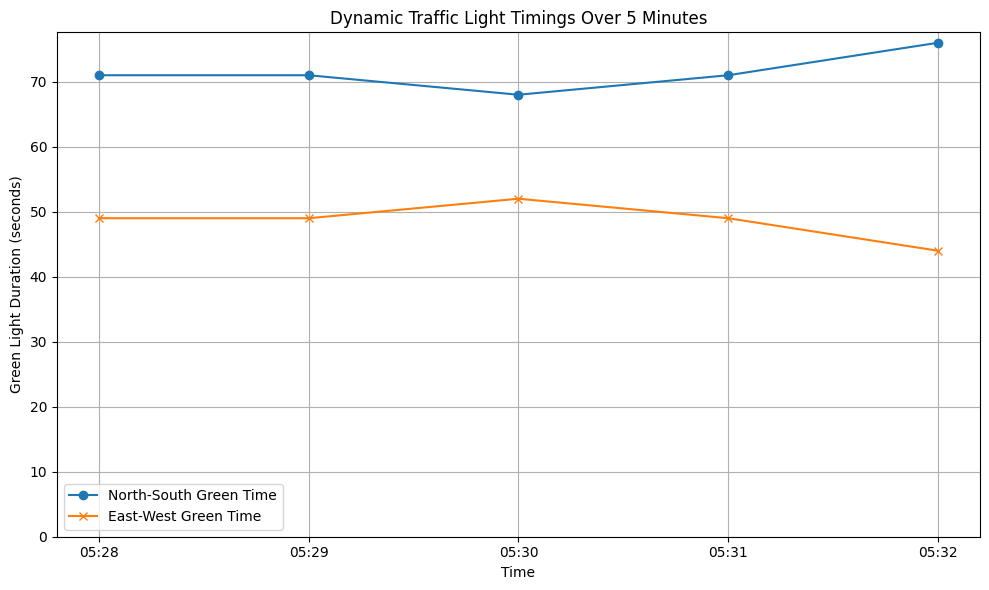

Dynamic Timings DataFrame:


,Time,North-South Green (s),East-West Green (s)
0,05:28,71,49
1,05:29,71,49
2,05:30,68,52
3,05:31,71,49
4,05:32,76,44


In [11]:
import matplotlib.pyplot as plt

# Re-run the 5-minute simulation to store all timings
sim_times = []
ns_timings = []
ew_timings = []

start_analysis_time = datetime.datetime.now()

for i in range(5):
    sim_time = start_analysis_time + datetime.timedelta(minutes=i)
    sim_snapshot = get_realtime_traffic_snapshot(sim_time)
    sim_timings_dict = dynamic_traffic_light_control(sim_snapshot)

    sim_times.append(sim_time.strftime('%H:%M'))
    ns_timings.append(sim_timings_dict['North-South'])
    ew_timings.append(sim_timings_dict['East-West'])

# Create a DataFrame for plotting
timings_df = pd.DataFrame({
    'Time': sim_times,
    'North-South Green (s)': ns_timings,
    'East-West Green (s)': ew_timings
})

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(timings_df['Time'], timings_df['North-South Green (s)'], marker='o', label='North-South Green Time')
plt.plot(timings_df['Time'], timings_df['East-West Green (s)'], marker='x', label='East-West Green Time')

plt.xlabel('Time')
plt.ylabel('Green Light Duration (seconds)')
plt.title('Dynamic Traffic Light Timings Over 5 Minutes')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0) # Ensure y-axis starts from 0
plt.tight_layout()
plt.show()

print("Dynamic Timings DataFrame:")
display(timings_df)

### 5. Calculating Performance Metrics: Average Delay and Queue Length

To quantify the effectiveness of our dynamic traffic light system, we need to define and calculate relevant performance metrics. For this simulation, we'll focus on:

*   **Average Queue Length:** The average number of vehicles waiting at an approach over time.
*   **Average Delay:** A proxy for the time vehicles spend waiting, approximated by the product of queue length and traffic volume.

These metrics will be calculated over the entire simulated `traffic_df` data.

In [12]:
# Calculate average queue length
average_queue_length = traffic_df['queue_length'].mean()
print(f"Average Queue Length across all approaches and time steps: {average_queue_length:.2f} vehicles")

# Calculate a proxy for delay for each entry
# A more sophisticated model would simulate vehicle movement and actual waiting times
traffic_df['delay_proxy'] = traffic_df['queue_length'] * traffic_df['traffic_volume']

# Calculate average delay proxy
average_delay_proxy = traffic_df['delay_proxy'].mean()
print(f"Average Delay Proxy (queue_length * traffic_volume) across all approaches and time steps: {average_delay_proxy:.2f}")

# Optionally, let's look at these metrics broken down by approach
print("\nMetrics by Approach:")
metrics_by_approach = traffic_df.groupby('approach').agg(
    avg_queue_length=('queue_length', 'mean'),
    avg_delay_proxy=('delay_proxy', 'mean')
).reset_index()
display(metrics_by_approach)

Average Queue Length across all approaches and time steps: 6.82 vehicles
Average Delay Proxy (queue_length * traffic_volume) across all approaches and time steps: 132.55

Metrics by Approach:


,approach,avg_queue_length,avg_delay_proxy
0,East,7.033333,144.633333
1,North,6.850000,118.033333
2,South,6.400000,124.250000
3,West,7.000000,143.283333


In [1]:
!git clone https://github.com/Tanay-Mehta09/Smart-traffic-management-system.git

Cloning into 'Smart-traffic-management-system'...


In [2]:
!cp -r /content/project/* /content/Smart-Traffic-Light-Management-System/

cp: cannot stat '/content/project/*': No such file or directory


In [3]:
!pwd
!ls

/content
sample_data  Smart-traffic-management-system


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!find /content/drive -type d | head -100

/content/drive
/content/drive/.shortcut-targets-by-id
/content/drive/MyDrive
/content/drive/MyDrive/Classroom
/content/drive/MyDrive/Classroom/SME(102003) (F.E_2023-2024)
/content/drive/MyDrive/Classroom/FE (2023-24) Div - D,E,F
/content/drive/MyDrive/Classroom/F. E. Div. E SEM I 2023-24
/content/drive/MyDrive/Classroom/FW WORKSHOP 2023-24
/content/drive/MyDrive/Classroom/First year Engineering 2023-2024 DIV-E
/content/drive/MyDrive/Classroom/Engineering Graphics (102012) F.E. 2023-2024
/content/drive/MyDrive/Classroom/ENGG. CHEM (SEM-II-2023-24)
/content/drive/MyDrive/Classroom/SE AI&DS 2024-2025
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB
/content/drive/MyDrive/Mukesh 
/content/drive/MyDrive/Padma
/content/drive/MyDrive/Siddhant 
/content/drive/MyDrive/Colab Notebooks
/content/drive/.Trash-0
/content/drive/.Trash-0/files
/content/drive/.Trash-0/info
/content/drive/.Encrypted
/content/drive/.Encrypted/.shortcut-targets-by-id
/content/drive/.Encrypted/MyDrive
/content/driv

In [6]:
!cp -r "/content/drive/MyDrive/YourProject/"* "/content/Smart-traffic-management-system/"

cp: cannot stat '/content/drive/MyDrive/YourProject/*': No such file or directory


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
!find "/content/drive/MyDrive" -maxdepth 2 -type d

/content/drive/MyDrive
/content/drive/MyDrive/Classroom
/content/drive/MyDrive/Classroom/SME(102003) (F.E_2023-2024)
/content/drive/MyDrive/Classroom/FE (2023-24) Div - D,E,F
/content/drive/MyDrive/Classroom/F. E. Div. E SEM I 2023-24
/content/drive/MyDrive/Classroom/FW WORKSHOP 2023-24
/content/drive/MyDrive/Classroom/First year Engineering 2023-2024 DIV-E
/content/drive/MyDrive/Classroom/Engineering Graphics (102012) F.E. 2023-2024
/content/drive/MyDrive/Classroom/ENGG. CHEM (SEM-II-2023-24)
/content/drive/MyDrive/Classroom/SE AI&DS 2024-2025
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB
/content/drive/MyDrive/Mukesh 
/content/drive/MyDrive/Padma
/content/drive/MyDrive/Siddhant 
/content/drive/MyDrive/Colab Notebooks


In [9]:
!find "/content/drive/MyDrive/Colab Notebooks" -maxdepth 2 -type d

/content/drive/MyDrive/Colab Notebooks


In [10]:
!find /content -maxdepth 2

/content
/content/.config
/content/.config/config_sentinel
/content/.config/gce
/content/.config/active_config
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/.last_opt_in_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/logs
/content/.config/configurations
/content/.config/default_configs.db
/content/drive
/content/drive/.shortcut-targets-by-id
/content/drive/MyDrive
/content/drive/.Trash-0
/content/drive/.Encrypted
/content/Smart-traffic-management-system
/content/Smart-traffic-management-system/.git
/content/sample_data
/content/sample_data/anscombe.json
/content/sample_data/README.md
/content/sample_data/california_housing_train.csv
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/mnist_test.csv


In [11]:
%cd /content/Smart-traffic-management-system

/content/Smart-traffic-management-system


In [12]:
!ls -la

total 12
drwxr-xr-x 3 root root 4096 Jul 10 10:02 .
drwxr-xr-x 1 root root 4096 Jul 10 10:05 ..
drwxr-xr-x 7 root root 4096 Jul 10 10:02 .git


In [13]:
.git

SyntaxError: invalid syntax (2015481467.py, line 1)

In [14]:
%cd /content/Smart-traffic-management-system
!pwd
!ls -la

/content/Smart-traffic-management-system
/content/Smart-traffic-management-system
total 12
drwxr-xr-x 3 root root 4096 Jul 10 10:02 .
drwxr-xr-x 1 root root 4096 Jul 10 10:05 ..
drwxr-xr-x 7 root root 4096 Jul 10 10:02 .git


In [15]:
!find /content -maxdepth 3 -type f

/content/.config/config_sentinel
/content/.config/gce
/content/.config/active_config
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/.last_opt_in_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/configurations/config_default
/content/.config/default_configs.db
/content/drive/MyDrive/Contact Information (1).gform
/content/drive/MyDrive/Untitled form (2).gform
/content/drive/MyDrive/Contact Information.gform
/content/drive/MyDrive/Untitled presentation.gslides
/content/drive/MyDrive/Untitled spreadsheet.gsheet
/content/drive/MyDrive/_.__ State Common Entrance Test Cell, Government of Maharashtra __._.pdf
/content/drive/MyDrive/Final Merit.pdf
/content/drive/MyDrive/23146691609092005 (2).pdf
/content/drive/MyDrive/Untitled.pdf
/content/drive/MyDrive/Event Registration (1).gform
/content/drive/MyDrive/Event Registration.gform
/content/drive/MyDrive/FPL 3 registration (Responses) 

In [16]:
!find "/content/drive/MyDrive" -maxdepth 3 -type f

/content/drive/MyDrive/Contact Information (1).gform
/content/drive/MyDrive/Untitled form (2).gform
/content/drive/MyDrive/Contact Information.gform
/content/drive/MyDrive/Untitled presentation.gslides
/content/drive/MyDrive/Untitled spreadsheet.gsheet
/content/drive/MyDrive/_.__ State Common Entrance Test Cell, Government of Maharashtra __._.pdf
/content/drive/MyDrive/Final Merit.pdf
/content/drive/MyDrive/23146691609092005 (2).pdf
/content/drive/MyDrive/Untitled.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/wt unit 4 (1).pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/wt unit 4.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/unit 4-1.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/unit 5.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/UNIT 6.pdf
/content/drive/MyDrive/Event Registration (1).gform
/content/drive/MyDrive/Event Registration.gform
/content/drive/MyDrive/FPL 3 registration (Responses) (1).gsheet
/content/d

In [17]:
!cp "/content/YourNotebook.ipynb" "/content/Smart-traffic-management-system/"

cp: cannot stat '/content/YourNotebook.ipynb': No such file or directory


In [18]:
!find /content -maxdepth 3 -type f

/content/.config/config_sentinel
/content/.config/gce
/content/.config/active_config
/content/.config/.last_survey_prompt.yaml
/content/.config/.last_update_check.json
/content/.config/.last_opt_in_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/configurations/config_default
/content/.config/default_configs.db
/content/drive/MyDrive/Contact Information (1).gform
/content/drive/MyDrive/Untitled form (2).gform
/content/drive/MyDrive/Contact Information.gform
/content/drive/MyDrive/Untitled presentation.gslides
/content/drive/MyDrive/Untitled spreadsheet.gsheet
/content/drive/MyDrive/_.__ State Common Entrance Test Cell, Government of Maharashtra __._.pdf
/content/drive/MyDrive/Final Merit.pdf
/content/drive/MyDrive/23146691609092005 (2).pdf
/content/drive/MyDrive/Untitled.pdf
/content/drive/MyDrive/Event Registration (1).gform
/content/drive/MyDrive/Event Registration.gform
/content/drive/MyDrive/FPL 3 registration (Responses) 

In [19]:
!find "/content/drive/MyDrive" -maxdepth 3 -type f

/content/drive/MyDrive/Contact Information (1).gform
/content/drive/MyDrive/Untitled form (2).gform
/content/drive/MyDrive/Contact Information.gform
/content/drive/MyDrive/Untitled presentation.gslides
/content/drive/MyDrive/Untitled spreadsheet.gsheet
/content/drive/MyDrive/_.__ State Common Entrance Test Cell, Government of Maharashtra __._.pdf
/content/drive/MyDrive/Final Merit.pdf
/content/drive/MyDrive/23146691609092005 (2).pdf
/content/drive/MyDrive/Untitled.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/wt unit 4 (1).pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/wt unit 4.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/unit 4-1.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/unit 5.pdf
/content/drive/MyDrive/Classroom/TE AI&DS 2025-26 TH+LAB/UNIT 6.pdf
/content/drive/MyDrive/Event Registration (1).gform
/content/drive/MyDrive/Event Registration.gform
/content/drive/MyDrive/FPL 3 registration (Responses) (1).gsheet
/content/d